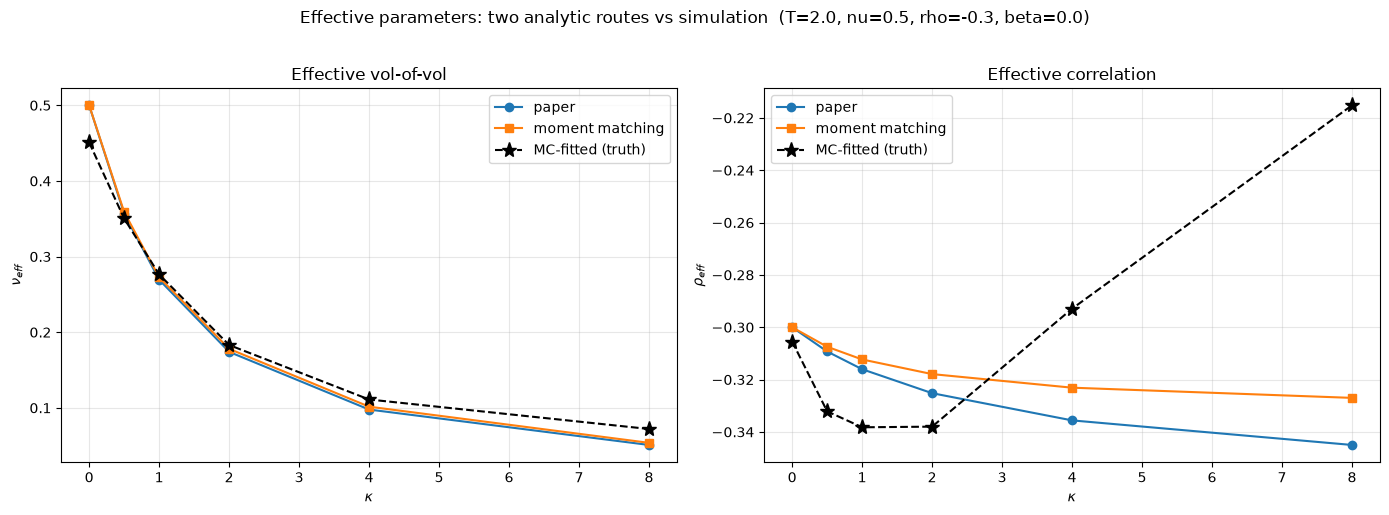

 kappa    nu_ac    nu_mm   nu_fit       rho_ac    rho_mm   rho_fit
  0.00    0.500    0.500    0.451       -0.300    -0.300    -0.305
  0.50    0.357    0.359    0.350       -0.309    -0.307    -0.332
  1.00    0.269    0.273    0.276       -0.316    -0.312    -0.338
  2.00    0.174    0.178    0.183       -0.325    -0.318    -0.338
  4.00    0.098    0.102    0.111       -0.336    -0.323    -0.293
  8.00    0.051    0.054    0.072       -0.345    -0.327    -0.215


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import european_analytics
from models import mSABR

# config
F0, lambda_ = 0.05, 0.04
F_s   = F0 + lambda_
beta, nu, rho, sigma_atm = 0.0, 0.5, -0.3, 0.01
T = 2.0
N_PATHS, N_STEPS, SEED = 40_000, 1000, 42

kappas = [0.0, 0.5, 1.0, 2.0, 4.0, 8.0]
K_grid = F_s * np.exp(np.linspace(-0.8, 0.8, 31))

def mc_smile(kappa):
    """mrSABR MC smile + the object (which already carries autocorr nu_eff/rho_eff)."""
    an  = european_analytics.EuropeanAnalyticsMRSABR(F_s, T, beta, nu, rho, sigma_atm, lambda_, kappa)
    sim = mSABR(F0=F_s, A0=an.alpha, rho=rho, T=T, n_steps=N_STEPS, n_paths=N_PATHS,
                beta=beta, nu=nu, kappa=kappa, theta=an.alpha, seed=SEED)
    F_shifted = sim.run()[0][:, -1]
    return an, an.implied_vol_smile_mc(F_shifted, K_grid)

rows = []
for kap in kappas:
    an, v_mc = mc_smile(kap)
    nu_ac, rho_ac = an.nu_eff, an.rho_eff                                                              
    nu_mm, rho_mm, _, _ = european_analytics.EuropeanAnalyticsMRSABR.mr_effective_params_mm(kap, T, nu, rho) 
    nu_fit, rho_fit = european_analytics.EuropeanAnalyticsSABR.fit_effective_params(v_mc, K_grid, F_s, T, beta, sigma_atm, lambda_)
    rows.append((kap, nu_ac, rho_ac, nu_mm, rho_mm, nu_fit, rho_fit))

kaps = [r[0] for r in rows]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(kaps, [r[1] for r in rows], 'o-',  label='paper')
axes[0].plot(kaps, [r[3] for r in rows], 's-',  label='moment matching')
axes[0].plot(kaps, [r[5] for r in rows], 'k*--', ms=11, label='MC-fitted (truth)')
axes[0].set_xlabel(r'$\kappa$'); axes[0].set_ylabel(r'$\nu_{eff}$')
axes[0].set_title('Effective vol-of-vol'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(kaps, [r[2] for r in rows], 'o-',  label='paper')
axes[1].plot(kaps, [r[4] for r in rows], 's-',  label='moment matching')
axes[1].plot(kaps, [r[6] for r in rows], 'k*--', ms=11, label='MC-fitted (truth)')
axes[1].set_xlabel(r'$\kappa$'); axes[1].set_ylabel(r'$\rho_{eff}$')
axes[1].set_title('Effective correlation'); axes[1].legend(); axes[1].grid(alpha=0.3)
fig.suptitle(f'Effective parameters: two analytic routes vs simulation  '
             f'(T={T}, nu={nu}, rho={rho}, beta={beta})', y=1.02)
plt.tight_layout(); plt.show()

print(f"{'kappa':>6}{'nu_ac':>9}{'nu_mm':>9}{'nu_fit':>9}   {'rho_ac':>10}{'rho_mm':>10}{'rho_fit':>10}")
for kap, na, ra, nm, rm, nf, rf in rows:
    print(f"{kap:6.2f}{na:9.3f}{nm:9.3f}{nf:9.3f}   {ra:+10.3f}{rm:+10.3f}{rf:+10.3f}")

In [ ]:
import matplotlib.pyplot as plt
from stats import PathStatistics

kappas = [0.0, 0.5, 1.0, 2.0, 4.0, 8.0]

rows = []
for kap in kappas:
    an  = european_analytics.EuropeanAnalyticsMRSABR(F_s, T, beta, nu, rho, sigma_atm, lambda_, kap)
    sim = mSABR(F0=F_s, A0=an.alpha, rho=rho, T=T, n_steps=N_STEPS, n_paths=N_PATHS,
                beta=beta, nu=nu, kappa=kap, theta=an.alpha, seed=SEED)
    F_T = sim.run()[0][:, -1] - lambda_                       # de-shift to the real forward

    _,_,s_mm, k_mm = european_analytics.EuropeanAnalyticsMRSABR.mr_effective_params_mm(kap, T, nu, rho)
    s_mc = PathStatistics.skewness(F_T)
    k_mc = PathStatistics.kurtosis(F_T)
    rows.append((kap, s_mm, s_mc, k_mm, k_mc))

kaps = [r[0] for r in rows]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(kaps, [r[1] for r in rows], 's-', color='tab:orange', label='moment matching (analytic)')
axes[0].plot(kaps, [r[2] for r in rows], 'k*--', ms=11, label='MC (simulated)')
axes[0].set_xlabel(r'$\kappa$'); axes[0].set_ylabel('skewness of $F_T$')
axes[0].set_title('Skewness'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(kaps, [r[3] for r in rows], 's-', color='tab:orange', label='moment matching (analytic)')
axes[1].plot(kaps, [r[4] for r in rows], 'k*--', ms=11, label='MC (simulated)')
axes[1].set_xlabel(r'$\kappa$'); axes[1].set_ylabel('excess kurtosis of $F_T$')
axes[1].set_title('Excess kurtosis'); axes[1].legend(); axes[1].grid(alpha=0.3)
fig.suptitle(f'Moment matching: analytic vs simulated moments of $F_T$  '
             f'(T={T}, nu={nu}, rho={rho}, beta={beta})', y=1.02)
plt.tight_layout(); plt.show()

print(f"{'kappa':>6}{'skew_mm':>10}{'skew_mc':>10}{'kurt_mm':>10}{'kurt_mc':>10}")
for kap, sm, sc, km, kc in rows:
    print(f"{kap:6.2f}{sm:+10.3f}{sc:+10.3f}{km:+10.3f}{kc:+10.3f}")

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from scipy.optimize import least_squares

kap_fix = 2.0
T_fix   = 2.0
rhos    = [-0.7, -0.5, -0.3, -0.1, 0.1, 0.3, 0.5, 0.7]
K_grid  = F_s * np.exp(np.linspace(-0.8, 0.8, 31))

def fit_effective_sabr(mc_vols, x0=(0.2, -0.2)):
    mask = np.isfinite(mc_vols)
    def resid(p):
        nu_t, rho_t = p
        try:
            an = european_analytics.EuropeanAnalyticsSABR(F_s, T_fix, beta, nu_t, rho_t, sigma_atm, lambda_)
            return (an.implied_vol_smile(K_grid)[mask] - mc_vols[mask]) * 1e4
        except Exception:
            return np.full(mask.sum(), 1e6)
    return least_squares(resid, x0=list(x0), bounds=([1e-4, -0.999], [3.0, 0.999])).x

rows = []
for rho_i in rhos:
    an_ac = european_analytics.EuropeanAnalyticsMRSABR(F_s, T_fix, beta, nu, rho_i, sigma_atm, lambda_, kap_fix)
    sim = mSABR(F0=F_s, A0=an_ac.alpha, rho=rho_i, T=T_fix, n_steps=N_STEPS, n_paths=N_PATHS,
                beta=beta, nu=nu, kappa=kap_fix, theta=an_ac.alpha, seed=SEED)
    v_mc = an_ac.implied_vol_smile_mc(sim.run()[0][:, -1], K_grid)

    nu_ac, rho_ac = an_ac.nu_eff, an_ac.rho_eff
    nu_mm, rho_mm = european_analytics.EuropeanAnalyticsMRSABR.mr_effective_params_mm(kap_fix, T_fix, nu, rho_i)
    nu_fit, rho_fit = fit_effective_sabr(v_mc, x0=(nu_mm, rho_i))
    rows.append((rho_i, nu_ac, nu_mm, nu_fit, rho_ac, rho_mm, rho_fit))

rr = [r[0] for r in rows]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(rr, [r[1] for r in rows], 'o-',  label='autocorrelation (paper)')
axes[0].plot(rr, [r[2] for r in rows], 's-',  label='moment matching')
axes[0].plot(rr, [r[3] for r in rows], 'k*--', ms=11, label='MC-fitted (truth)')
axes[0].set_xlabel(r'$\rho$'); axes[0].set_ylabel(r'$\nu_{eff}$')
axes[0].set_title(f'Effective vol-of-vol vs rho  (kappa={kap_fix})'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(rr, [r[4] for r in rows], 'o-',  label='autocorrelation (paper)')
axes[1].plot(rr, [r[5] for r in rows], 's-',  label='moment matching')
axes[1].plot(rr, [r[6] for r in rows], 'k*--', ms=11, label='MC-fitted (truth)')
axes[1].set_xlabel(r'$\rho$'); axes[1].set_ylabel(r'$\rho_{eff}$')
axes[1].set_title(f'Effective correlation vs rho  (kappa={kap_fix})'); axes[1].legend(); axes[1].grid(alpha=0.3)
fig.suptitle(f'rho-probe: where the two routes split  (T={T_fix}, nu={nu}, beta={beta}, kappa={kap_fix})', y=1.02)
plt.tight_layout(); plt.show()

print(f"{'rho':>6}{'nu_ac':>9}{'nu_mm':>9}{'nu_fit':>9}   {'rho_ac':>9}{'rho_mm':>9}{'rho_fit':>9}")
for ri, na, nm, nf, ra, rm, rf in rows:
    print(f"{ri:+6.2f}{na:9.3f}{nm:9.3f}{nf:9.3f}   {ra:+9.3f}{rm:+9.3f}{rf:+9.3f}")